<a href="https://colab.research.google.com/github/mekhanaa/mekhanaa/blob/main/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Dataset Selection**

A Housing Price dataset is selected for this machine learning project. The dataset contains various features related to houses such as area, number of bedrooms, bathrooms, stories, parking, and furnishing status.

The main goal is to build a supervised machine learning regression model that can predict house prices based on these features.

##**Problem Definition**

The objective of this project is to predict house prices based on different property features using supervised machine learning.

The model will learn patterns between input features such as area, bedrooms, bathrooms, stories, parking, and furnishing status to estimate the final price of a house.

###Type of Problem: Regression (Supervised Learning)

###Target Variable: price

###Input Features: area, bedrooms, bathrooms, stories, parking, mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus

##**Data Loading**

In [3]:
df=pd.read_csv("/content/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
print("Shape:",df.shape)
print("Columns:",df.columns)

Shape: (545, 13)
Columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


##Insight:

The dataset contains both numerical and categorical variables and does not have missing values, making it suitable for further preprocessing and analysis.

##**Data Cleaning & Preprocessing**

In [9]:
print("Duplicated:",df.duplicated().sum())

Duplicated: 0


In [10]:
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [11]:
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [12]:
df["furnishingstatus"] = df["furnishingstatus"].astype(str).str.strip().str.lower()

df["furnishingstatus"] = df["furnishingstatus"].map({
    "unfurnished": 0,
    "semi-furnished": 1,
    "furnished": 2
})

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


##Insight:

All categorical variables have been successfully converted into numerical format, making the dataset ready for machine learning model training.

##**Univariate Analysis (Distribution)**

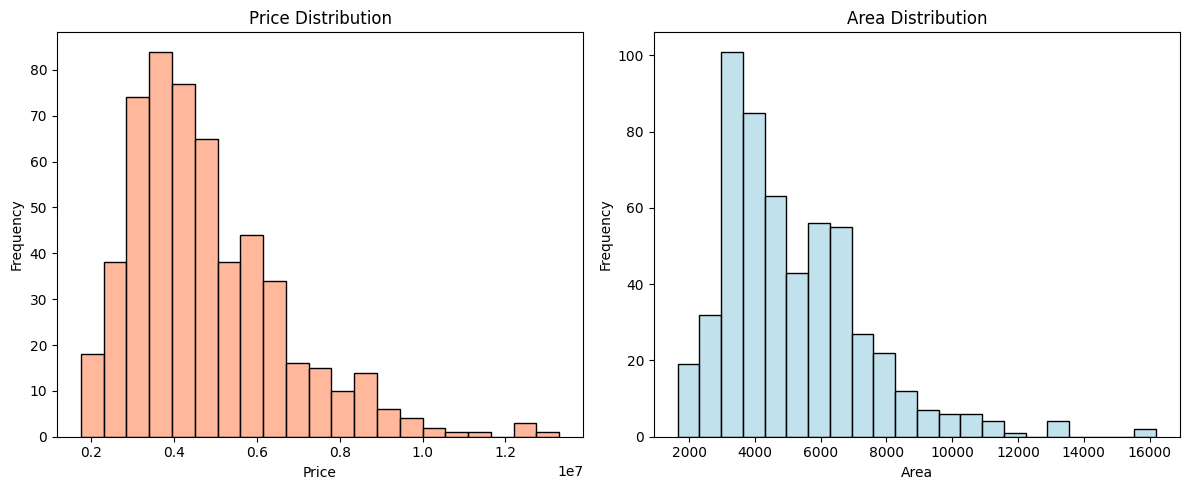

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], color="lightsalmon")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.histplot(df['area'], color="lightblue")
plt.title("Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

##Insight:

Both price and area are right-skewed, meaning most houses are concentrated in lower to mid ranges with a few high-value outliers.

##**Bivariate Analysis**

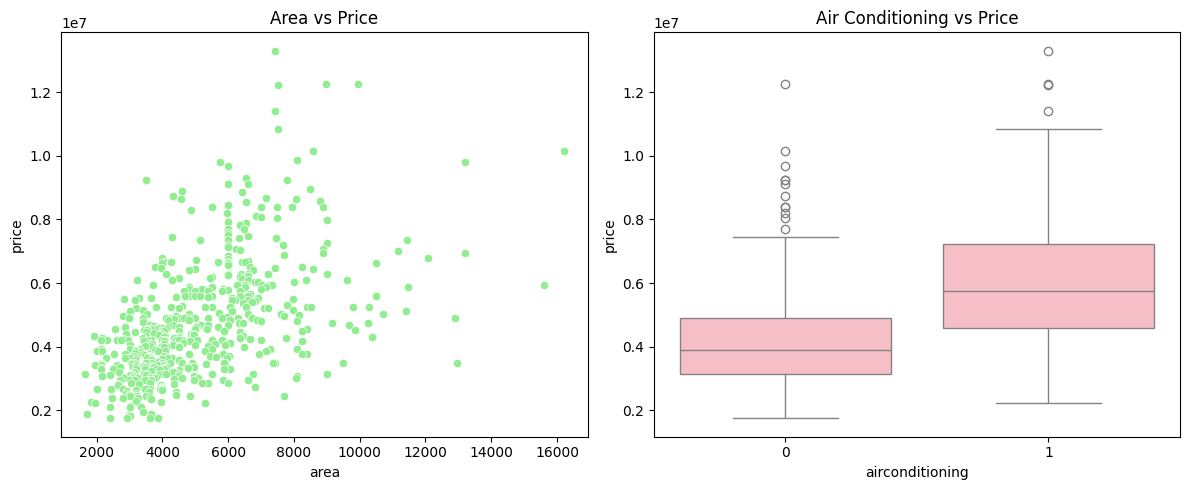

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df['area'], y=df['price'],color="lightgreen")
plt.title("Area vs Price")

plt.subplot(1,2,2)
sns.boxplot(x=df['airconditioning'], y=df['price'],color="lightpink")
plt.title("Air Conditioning vs Price")

plt.tight_layout()
plt.show()

##Insight:

House price increases with area, and houses with air conditioning generally have higher price distribution.

##**Correlation Analysis**

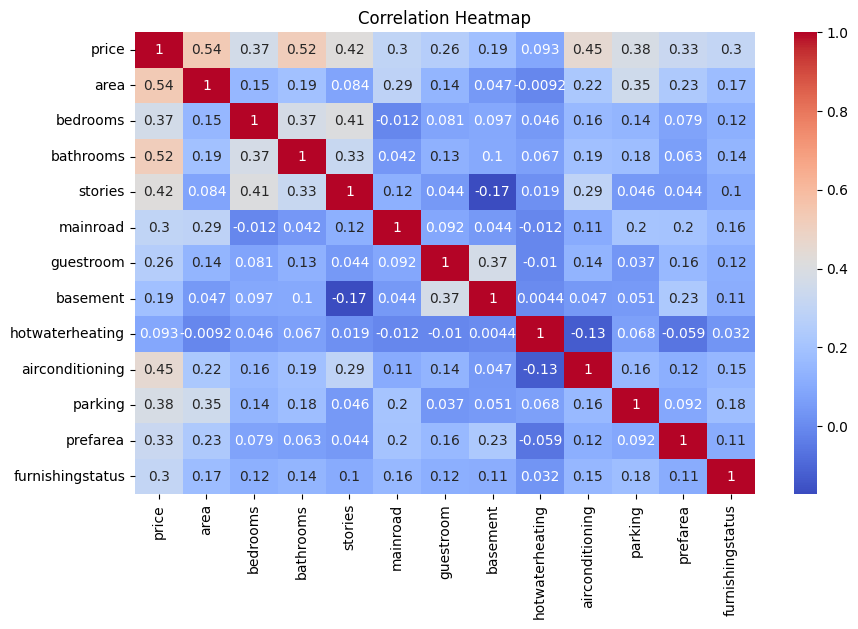

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##Insight:

Area, bathrooms, and air conditioning show relatively stronger correlation with price compared to other features.

##**Data Preprocessing (Train–Test Split)**

In [22]:
x=df.drop("price",axis=1)
y=df["price"]

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((436, 12), (109, 12), (436,), (109,))

##Insight:

The dataset is split into training and testing sets (80% training and 20% testing) to evaluate the model's performance on unseen data.

##**Model Building (Linear Regression)**

In [25]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [26]:
y_pred=model.predict(x_test)
y_pred[:10]

array([5203691.70963178, 7257004.02115475, 3062828.59668171,
       4559591.65374424, 3332932.30559782, 3563080.67918997,
       5645466.31219972, 6413979.66873635, 2755831.54819   ,
       2668938.66075228])

##Insight:

The Linear Regression model has been trained successfully and is now able to predict house prices based on input features.

##**Model Evaluation**

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Absolute Error: 979679.6912959901
Mean Squared Error: 1771751116594.0352
Root Mean Squared Error: 1331071.4167895108
R2 Score: 0.6494754192267803


##Insight:

The model performance is evaluated using R², MAE, and RMSE, which measure how well the model predicts house prices on unseen data.

##**Result Interpretation**

The Linear Regression model shows the relationship between house features and price.

R² score indicates how well the model explains price variation, while MAE and RMSE represent prediction errors in actual units.

##Insight:

The model performance metrics help evaluate how accurately the model predicts house prices on unseen test data.

##**Final Conclusion**

This project successfully demonstrates the use of supervised machine learning for predicting house prices using Linear Regression.

The dataset was analyzed using EDA, cleaned, and preprocessed by encoding categorical variables. The model was trained on 80% of the data and tested on 20% of unseen data.

The results show that house price can be reasonably predicted using features such as area, bathrooms, bedrooms, and other property attributes.

##Insight:

EDA helped identify key features influencing house prices, and Linear Regression provided a simple but effective baseline model for prediction.